In [ ]:
# ----------------------------------------------------------------------------------------------------------------
# This file contains the code supplementary to the paper:
# Robust Moment-Based Estimation via Spectral Gradient Reweighting

# Copyright (c) 2026 Liu Zhang

# SPDX-License-Identifier: GPL-3.0-only

# This program is free software: you can redistribute it and/or modify it under the terms of 
# the GNU General Public License as published by the Free Software Foundation, version 3.

# This program is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; 
# without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. 
# See the GNU General Public License for more details.

# You should have received a copy of the GNU General Public License along with this program. 
# If not, see <https://www.gnu.org/licenses/>. 

# Author: Liu Zhang (lz1619@princeton.edu), Program in Applied and Computational Mathematics, Princeton University
# Last update date: 2026-05-25
# ----------------------------------------------------------------------------------------------------------------


# Numerical Experiments for Robust Gradient Reweighting ($\verb+SGR+$) Algorithm: 

This notebook provides the numerical experiments in Section 5.1 of [1] to validate the $\verb+SGR+$ primitive on a synthetic contaminated gradient clouds $\{g_n\}_{n=1}^N \subset \mathbb{R}^p$.

[1] Liu Zhang, Amit Singer. Robust Moment-Based Estimation via Spectral Gradient Reweighting.

General notes on reproducibility: 
* All data are saved under the folder ```tests/test_data```. 
* All plots are saved under the folder ```figures/```.
* To ensure reproducibility as much as possible, all random functions use a fixed seed number. However, non-zero run-to-run variabilities might still occur. This is due to multi-threaded BLAS/LAPACK functions like ```np.linalg.cholesky```, ```np.linalg.solve```. These run-to-run variabilities do not affect the general conclusions. To minimize such run-to-run variabilities, each simulation has been run multiple times to ensure that the results are consistent across multiple runs. 
* When the code is run on a different device, the actual estimation results might differ slightly from the ones in this notebook. These device-to-device variabilities do not affect the general conclusions. To minimize such device-to-device variabilities, it is recommended to set up a virtual environment and use the pinned versions for the dependencies listed below (especially for ```numpy``` and ```scipy``` since they tend to have more frequent release of substantial updates.) See ```README.rst``` file for installation instructions.
    * ```python==3.11.11```
    * ```numpy==1.26.4```
    * ```scipy==1.15.3```
    * ```scikit-learn==1.7.0```
    * ```sympy==1.14.0```
    * ```matplotlib==3.7.2```
    * ```seaborn==0.12.2```
* If the scripts are run with a different version of Python or other packages, small numerical variabilities might occur. These variabilities do not affect the general conclusions.

In [ ]:
from gmm import GMM
from robust_dgmm import RobustDGMM
from gm_moments import GaussianMixtureMoments
from robust_gradient_reweighting import RobustGradientReweighting
from utils import params_to_theta, compute_average_error, theta_to_params, generate_ground_truth, generate_initial_parameters, plot_comparison_figure, additive_noise, huber_epsilon_contamination
from NystromApprox import compute_moment_sums, compute_exact_moment_sums

from __future__ import annotations

import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import loadmat, savemat
import scipy
import importlib.util
import os
import random
import sys
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [5]:
import importlib.util
import os
import random
import sys
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [6]:
# Set seed for reproducibility.
SEED = 4142
random.seed(SEED)
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

In [7]:
# Check versions.
print("Python executable:", sys.executable)
print("Python version   :", sys.version)
print("numpy version    :", np.__version__)
print("pandas version   :", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)

Python executable: /Users/lz1619/Documents/manifoldmoments-dev/manifoldmoments-dev-venv/bin/python3.11
Python version   : 3.11.11 (main, Dec  3 2024, 17:20:40) [Clang 16.0.0 (clang-1600.0.26.4)]
numpy version    : 1.26.4
pandas version   : 2.3.2
matplotlib version: 3.7.2


## Helper functions

In [8]:
import matplotlib as mpl


mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif", 
    "axes.formatter.use_mathtext": True,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "axes.unicode_minus": False,
})

def plot_mean_with_band(ax, summary_df, x_col, mean_col, std_col, label, marker):
    x = summary_df[x_col].to_numpy(dtype=float)
    y = summary_df[mean_col].to_numpy(dtype=float)
    s = summary_df[std_col].to_numpy(dtype=float)
    line = ax.plot(x, y, marker=marker, label=label)[0]
    ax.fill_between(x, y - s, y + s, color=line.get_color(), alpha=0.10, linewidth=0.0)

FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_pdf(fig, name):
    path = FIG_DIR / name
    fig.savefig(path, format="pdf", bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)
    print(f"saved: {path}")

In [9]:

def compute_weighted_mean(points: np.ndarray, weights: np.ndarray) -> np.ndarray:
    return np.einsum("n,ni->i", weights, points, optimize=True)


def compute_weighted_second_moment(
    points: np.ndarray,
    center: np.ndarray,
    weights: np.ndarray,
) -> np.ndarray:
    centered_points = points - center[np.newaxis, :]
    matrix = np.einsum("n,ni,nj->ij", weights, centered_points, centered_points, optimize=True)
    return 0.5 * (matrix + matrix.T)


def spectral_norm(symmetric_matrix: np.ndarray) -> float:
    eigenvalues = np.linalg.eigvalsh(0.5 * (symmetric_matrix + symmetric_matrix.T))
    return float(np.max(eigenvalues))


def relative_error_norm(mu_estimated: np.ndarray, mu_true: np.ndarray) -> float:
    mu_true_norm = float(np.linalg.norm(mu_true))
    if mu_true_norm <= 0.0:
        raise ValueError("The true mean has zero norm, so the relative error is undefined.")
    return float(np.linalg.norm(mu_estimated - mu_true) / mu_true_norm)


def coordinatewise_median(points: np.ndarray) -> np.ndarray:
    return np.median(points, axis=0)


def geometric_median(
    points: np.ndarray,
    tol: float = 1e-8,
    max_iter: int = 200,
) -> np.ndarray:
    center = np.mean(points, axis=0)
    for _ in range(max_iter):
        differences = points - center[np.newaxis, :]
        distances = np.linalg.norm(differences, axis=1)

        close_mask = distances <= tol
        if np.any(close_mask):
            return points[np.argmin(distances)].copy()

        inverse_distances = 1.0 / distances
        next_center = (
            np.sum(points * inverse_distances[:, None], axis=0)
            / np.sum(inverse_distances)
        )

        if np.linalg.norm(next_center - center) <= tol * max(1.0, np.linalg.norm(center)):
            return next_center

        center = next_center

    return center


def effective_sample_size(weights: np.ndarray) -> float:
    return float(1.0 / np.sum(np.square(weights)))


def make_mu_true(dim_p: int) -> np.ndarray:
    mu_true = np.zeros(dim_p, dtype=np.float64)
    template = np.array([0.50, -0.50, 0.25, 0.00, 0.75], dtype=np.float64)
    mu_true[: min(dim_p, template.size)] = template[: min(dim_p, template.size)]
    return mu_true


def make_inlier_covariance(dim_p: int, low_rank_bias: bool = True) -> np.ndarray:
    if dim_p == 1:
        return np.array([[1.0]], dtype=np.float64)

    if low_rank_bias:
        eigenvalues = np.exp(-np.linspace(0.0, 2.0, dim_p))
    else:
        eigenvalues = np.linspace(1.0, 0.4, dim_p)

    return np.diag(eigenvalues.astype(np.float64))


def smallest_eigenvector(covariance: np.ndarray) -> np.ndarray:
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    direction = eigenvectors[:, np.argmin(eigenvalues)]
    direction /= np.linalg.norm(direction)
    return direction


def summarise_metric(
    results_df: pd.DataFrame,
    group_cols: list[str],
    metric_cols: list[str],
) -> pd.DataFrame:
    grouped = (
        results_df.groupby(group_cols, dropna=False)[metric_cols]
        .agg(["mean", "std"])
        .reset_index()
    )
    grouped.columns = [
        "_".join(column).strip("_") if isinstance(column, tuple) else column
        for column in grouped.columns.to_flat_index()
    ]
    return grouped


## Synthetic-gradient model

In [10]:

@dataclass(frozen=True)
class SyntheticGradientExperimentConfig:
    n_inliers: int
    n_outliers: int
    dim_p: int
    epsilon_assumed: float | None = None
    outlier_mode: str = "far_cluster"
    outlier_strength: float = 8.0
    outlier_box_low: float = 4.0
    outlier_box_high: float = 10.0
    outlier_variance_scale: float = 0.10
    use_exact_diameter: bool = True
    step_max_outer: int = 8
    step_max_inner: int = 100
    step_size_strategy: str = "max_safe"
    threshold_const: float | None = None
    target_accuracy: float = 1e-4
    warm_start_inner_weights: bool = True
    initial_center_strategy: str = "geometric_median"
    low_rank_bias: bool = True


def generate_contaminated_gradient_cloud(
    config: SyntheticGradientExperimentConfig,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    dim_p = config.dim_p
    mu_true = make_mu_true(dim_p)
    inlier_covariance = make_inlier_covariance(dim_p, low_rank_bias=config.low_rank_bias)

    gradients_inlier = rng.multivariate_normal(
        mu_true,
        inlier_covariance,
        size=config.n_inliers,
    )

    direction = smallest_eigenvector(inlier_covariance)
    noise_covariance = config.outlier_variance_scale * np.eye(dim_p, dtype=np.float64)

    if config.n_outliers == 0:
        gradients_outlier = np.empty((0, dim_p), dtype=np.float64)
    elif config.outlier_mode == "far_cluster":
        outlier_mean = mu_true + config.outlier_strength * np.ones(dim_p, dtype=np.float64)
        gradients_outlier = rng.multivariate_normal(
            outlier_mean,
            noise_covariance,
            size=config.n_outliers,
        )
    elif config.outlier_mode == "directional_smallest_eigenvector":
        outlier_mean = mu_true + config.outlier_strength * direction
        gradients_outlier = rng.multivariate_normal(
            outlier_mean,
            noise_covariance,
            size=config.n_outliers,
        )
    elif config.outlier_mode == "uniform_box":
        theta = rng.uniform(
            low=config.outlier_box_low,
            high=config.outlier_box_high,
            size=(config.n_outliers, dim_p),
        )
        gradients_outlier = theta + rng.multivariate_normal(
            np.zeros(dim_p, dtype=np.float64),
            noise_covariance,
            size=config.n_outliers,
        )
    elif config.outlier_mode == "nearby_cluster":
        shift = np.zeros(dim_p, dtype=np.float64)
        shift[: min(2, dim_p)] = 1.5
        outlier_mean = mu_true + shift
        gradients_outlier = rng.multivariate_normal(
            outlier_mean,
            inlier_covariance,
            size=config.n_outliers,
        )
    else:
        raise ValueError(f"Unknown outlier_mode: {config.outlier_mode}")

    per_sample_gradients = np.vstack((gradients_inlier, gradients_outlier))
    outlier_mask = np.array(
        [False] * config.n_inliers + [True] * config.n_outliers,
        dtype=bool,
    )

    permutation = rng.permutation(config.n_inliers + config.n_outliers)
    per_sample_gradients = per_sample_gradients[permutation, :]
    outlier_mask = outlier_mask[permutation]

    return per_sample_gradients, outlier_mask, mu_true, inlier_covariance


In [11]:

def run_single_trial(
    config: SyntheticGradientExperimentConfig,
    seed: int,
    return_history: bool = False,
    eta_rho: float | None = None,
    eta_w: float | None = None,
) -> tuple[dict, dict | None]:
    local_rng = np.random.default_rng(seed)
    per_sample_gradients, outlier_mask, mu_true, _ = generate_contaminated_gradient_cloud(
        config,
        local_rng,
    )

    n_points = per_sample_gradients.shape[0]
    actual_epsilon = config.n_outliers / n_points
    epsilon_assumed = actual_epsilon if config.epsilon_assumed is None else config.epsilon_assumed

    uniform_weights = np.full(n_points, 1.0 / n_points, dtype=np.float64)
    uniform_mean = compute_weighted_mean(per_sample_gradients, uniform_weights)
    coordinatewise_median_estimate = coordinatewise_median(per_sample_gradients)
    geometric_median_estimate = geometric_median(per_sample_gradients)
    oracle_inlier_mean = np.mean(per_sample_gradients[~outlier_mask, :], axis=0)

    start_time = time.perf_counter()
    reweighter = RobustGradientReweighting(
        contamination_epsilon=epsilon_assumed,
        n_points=n_points,
        dim_p=config.dim_p,
        eta_rho=eta_rho,
        eta_w=eta_w,
        step_max_outer=config.step_max_outer,
        step_max_inner=config.step_max_inner,
        threshold_const=config.threshold_const,
        target_accuracy=config.target_accuracy,
        use_exact_diameter=config.use_exact_diameter,
        initial_center_strategy=config.initial_center_strategy,
        warm_start_inner_weights=config.warm_start_inner_weights,
        use_outer_center_safeguard=False,
        verbose=False,
        step_size_strategy=config.step_size_strategy,
        warn_on_theory_gap=False,
    )
    reweighter.fit(per_sample_gradients)
    runtime_seconds = time.perf_counter() - start_time

    robust_weights = reweighter.sample_weights
    robust_mean = reweighter.weighted_mean
    fixed_center = reweighter.fixed_center

    uniform_second_moment_at_fixed_center = compute_weighted_second_moment(
        per_sample_gradients,
        fixed_center,
        uniform_weights,
    )
    robust_second_moment_at_fixed_center = reweighter.weighted_second_moment

    result = {
        "seed": seed,
        "n_inliers": config.n_inliers,
        "n_outliers": config.n_outliers,
        "n_points": n_points,
        "dim_p": config.dim_p,
        "actual_epsilon": actual_epsilon,
        "epsilon_assumed": epsilon_assumed,
        "outlier_mode": config.outlier_mode,
        "outlier_strength": config.outlier_strength,
        "step_size_strategy": config.step_size_strategy,
        "step_max_outer": config.step_max_outer,
        "step_max_inner": config.step_max_inner,
        "target_accuracy": config.target_accuracy,
        "warm_start_inner_weights": config.warm_start_inner_weights,
        "initial_center_strategy": config.initial_center_strategy,
        "runtime_seconds": runtime_seconds,
        "sample_mean_error": float(np.linalg.norm(uniform_mean - mu_true)),
        "coordinatewise_median_error": float(np.linalg.norm(coordinatewise_median_estimate - mu_true)),
        "geometric_median_error": float(np.linalg.norm(geometric_median_estimate - mu_true)),
        "oracle_inlier_mean_error": float(np.linalg.norm(oracle_inlier_mean - mu_true)),
        "robust_weighted_mean_error": float(np.linalg.norm(robust_mean - mu_true)),
        "robust_relative_error": relative_error_norm(robust_mean, mu_true),
        "uniform_outlier_mass": float(np.sum(uniform_weights[outlier_mask])),
        "robust_outlier_mass": float(np.sum(robust_weights[outlier_mask])),
        "robust_inlier_mass": float(np.sum(robust_weights[~outlier_mask])),
        "uniform_second_moment_spectral_norm_at_fixed_center": spectral_norm(
            uniform_second_moment_at_fixed_center
        ),
        "robust_second_moment_spectral_norm_at_fixed_center": spectral_norm(
            robust_second_moment_at_fixed_center
        ),
        "robust_covariance_spectral_norm_about_weighted_mean": spectral_norm(
            reweighter.weighted_covariance_about_mean
        ),
        "weight_cap": float(reweighter.weight_cap_),
        "max_weight": float(np.max(robust_weights)),
        "sum_weights": float(np.sum(robust_weights)),
        "effective_sample_size": effective_sample_size(robust_weights),
        "outer_iterations": int(reweighter.n_outer_iter_),
        "total_inner_iterations": int(reweighter.n_iter_),
        "stopped_reason": reweighter.stopped_reason_,
        "converged": bool(reweighter.converged_),
    }

    history = None
    if return_history:
        history = {
            "mu_true": mu_true.copy(),
            "outlier_mask": outlier_mask.copy(),
            "spectral_norm_history": list(reweighter.spectral_norm_history),
            "weight_change_history": list(reweighter.weight_change_history),
            "center_shift_history": list(reweighter.center_shift_history),
            "location_error_history": [
                float(np.linalg.norm(center - mu_true))
                for center in reweighter.location_estimate_history
            ],
        }

    return result, history


def run_repeated_trials(
    config: SyntheticGradientExperimentConfig,
    seeds: Iterable[int],
    return_histories: bool = False,
    eta_rho: float | None = None,
    eta_w: float | None = None,
) -> tuple[pd.DataFrame, list[dict]]:
    rows: list[dict] = []
    histories: list[dict] = []

    for seed in seeds:
        result, history = run_single_trial(
            config,
            seed,
            return_history=return_histories,
            eta_rho=eta_rho,
            eta_w=eta_w,
        )
        rows.append(result)
        if history is not None:
            histories.append(history)

    return pd.DataFrame(rows), histories


## Experiment grid

In [12]:

SEED = 4142
random.seed(SEED)
np.random.seed(SEED)

FAST_MODE = False

if FAST_MODE:
    N_REPEATS = 3
    contamination_grid = np.array([0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40], dtype=float)
    epsilon_assumption_grid = [0.05, 0.08, 0.10, 0.12, 0.15, 0.20]
    inner_budget_grid = [50, 100, 200, 400]
    outlier_strength_grid = [4.0, 8.0, 16.0, 32.0]
else:
    N_REPEATS = 50
    contamination_grid = np.array([0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40], dtype=float)
    epsilon_assumption_grid = [0.05, 0.08, 0.10, 0.12, 0.15, 0.20]
    inner_budget_grid = [50, 100, 200, 400, 800]
    outlier_strength_grid = [4.0, 8.0, 16.0, 32.0, 64.0]

seed_grid = [SEED + 101 * j for j in range(N_REPEATS)]

print("FAST_MODE:", FAST_MODE)
print("N_REPEATS:", N_REPEATS)
print("seed_grid:", seed_grid)


FAST_MODE: False
N_REPEATS: 50
seed_grid: [4142, 4243, 4344, 4445, 4546, 4647, 4748, 4849, 4950, 5051, 5152, 5253, 5354, 5455, 5556, 5657, 5758, 5859, 5960, 6061, 6162, 6263, 6364, 6465, 6566, 6667, 6768, 6869, 6970, 7071, 7172, 7273, 7374, 7475, 7576, 7677, 7778, 7879, 7980, 8081, 8182, 8283, 8384, 8485, 8586, 8687, 8788, 8889, 8990, 9091]


## Experiments to check performance of algorithm 2:


### Experiment 1: Estimation error for different estimators under increasing contamination

This reproduces the contamination experiment with the updated practical defaults.
The theorem is only proved for the outer-loop contraction when `epsilon < 1/3`,
but the experiment also checks the heuristic behavior beyond that range.


In [14]:

contamination_results = []

total_points = 600
for epsilon_actual in contamination_grid:
    n_outliers = int(round(total_points * epsilon_actual))
    n_inliers = total_points - n_outliers
    config = SyntheticGradientExperimentConfig(
        n_inliers=n_inliers,
        n_outliers=n_outliers,
        dim_p=10,
        epsilon_assumed=epsilon_actual,
        outlier_mode="directional_smallest_eigenvector",
        outlier_strength=8.0,
        use_exact_diameter=True,
        step_max_outer=8,
        step_max_inner=100,
        step_size_strategy="max_safe",
        target_accuracy=1e-4,
        warm_start_inner_weights=True,
        initial_center_strategy="geometric_median",
    )
    result_df, _ = run_repeated_trials(config, seed_grid)
    contamination_results.append(result_df)

contamination_results_df = pd.concat(contamination_results, ignore_index=True)
contamination_summary_df = summarise_metric(
    contamination_results_df,
    group_cols=["actual_epsilon"],
    metric_cols=[
        "sample_mean_error",
        "coordinatewise_median_error",
        "geometric_median_error",
        "oracle_inlier_mean_error",
        "robust_weighted_mean_error",
        "robust_outlier_mass",
    ],
)
contamination_summary_df


,actual_epsilon,sample_mean_error_mean,sample_mean_error_std,coordinatewise_median_error_mean,coordinatewise_median_error_std,geometric_median_error_mean,geometric_median_error_std,oracle_inlier_mean_error_mean,oracle_inlier_mean_error_std,robust_weighted_mean_error_mean,robust_weighted_mean_error_std,robust_outlier_mass_mean,robust_outlier_mass_std
0,0.00,0.080974,0.023649,0.100964,0.025233,0.082986,0.023695,0.080974,0.023649,0.080974,0.023649,0.000000,0.000000
1,0.05,0.409591,0.011858,0.097125,0.020775,0.135460,0.016816,0.083070,0.024537,0.083092,0.024552,0.000041,0.000040
2,0.10,0.805504,0.011521,0.103515,0.018658,0.239032,0.014970,0.085458,0.025838,0.085506,0.025883,0.000076,0.000068
3,0.15,1.203936,0.011566,0.117817,0.016995,0.365699,0.015904,0.086619,0.026915,0.086691,0.026978,0.000106,0.000103
4,0.20,1.603148,0.011298,0.142773,0.016109,0.517636,0.015696,0.087800,0.028129,0.087862,0.028151,0.000129,0.000113
5,0.25,2.002792,0.011334,0.178101,0.018048,0.704960,0.017675,0.091641,0.026293,0.091704,0.026297,0.000148,0.000125
6,0.30,2.402461,0.011233,0.221792,0.020919,0.942775,0.020096,0.093339,0.028880,0.093378,0.028888,0.000162,0.000139
7,0.35,2.802184,0.011134,0.281839,0.023045,1.268021,0.023661,0.095654,0.028640,0.095683,0.028606,0.000184,0.000152
8,0.40,3.202014,0.011141,0.366527,0.028040,1.772602,0.032088,0.100258,0.028943,0.100303,0.028867,0.000217,0.000182


In [28]:
np.max(
    contamination_summary_df["robust_weighted_mean_error_mean"]
    - contamination_summary_df["oracle_inlier_mean_error_mean"]
)

7.243241265193767e-05

In [29]:
np.max(
    contamination_summary_df["robust_outlier_mass_mean"]
)

0.00021743633926334338

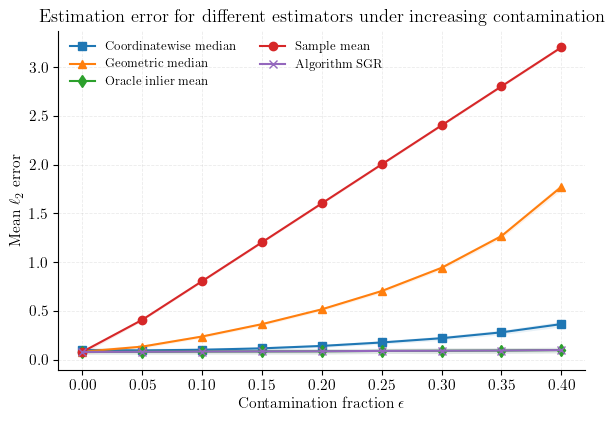

In [15]:
# ------------------------------------------------------------------
# 1. fig_contamination.pdf
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.8, 4.4))
plot_mean_with_band(ax, contamination_summary_df, "actual_epsilon",
                    "coordinatewise_median_error_mean", "coordinatewise_median_error_std",
                    "Coordinatewise median", marker="s")
plot_mean_with_band(ax, contamination_summary_df, "actual_epsilon",
                    "geometric_median_error_mean", "geometric_median_error_std",
                    "Geometric median", marker="^")
plot_mean_with_band(ax, contamination_summary_df, "actual_epsilon",
                    "oracle_inlier_mean_error_mean", "oracle_inlier_mean_error_std",
                    "Oracle inlier mean", marker="d")
plot_mean_with_band(ax, contamination_summary_df, "actual_epsilon",
                    "sample_mean_error_mean", "sample_mean_error_std",
                    "Sample mean", marker="o")
plot_mean_with_band(ax, contamination_summary_df, "actual_epsilon",
                    "robust_weighted_mean_error_mean", "robust_weighted_mean_error_std",
                    "Algorithm SGR", marker="x")
ax.set_title("Estimation error for different estimators under increasing contamination")
ax.set_xlabel(r"Contamination fraction $\epsilon$")
ax.set_ylabel(r"Mean $\ell_2$ error")
ax.legend(loc="upper left", ncol=2, fontsize=9)
plt.show() 

In [16]:
current_directory = os.getcwd()
parent_directory = os.path.dirname(current_directory)
contamination_results_df.to_csv(os.path.join(parent_directory,  'tests/test_data', 'contamination_results_df.csv'), index=True) 
contamination_summary_df.to_csv(os.path.join(parent_directory,  'tests/test_data', 'contamination_summary_df.csv'), index=True) 
save_pdf(fig, "fig_contamination.pdf")

saved: figures/fig_contamination.pdf



### Experiment 2: outer-loop diagnostics

The updated implementation should show that the outer loop refines the estimate
progressively rather than simply rediscovering the same reweighting from scratch.


In [17]:

diagnostic_config = SyntheticGradientExperimentConfig(
    n_inliers=540,
    n_outliers=60,
    dim_p=10,
    epsilon_assumed=0.10,
    outlier_mode="directional_smallest_eigenvector",
    outlier_strength=8.0,
    use_exact_diameter=True,
    step_max_outer=10,
    step_max_inner=100,
    step_size_strategy="max_safe",
    target_accuracy=1e-4,
    warm_start_inner_weights=True,
    initial_center_strategy="geometric_median",
)

diagnostic_results_df, diagnostic_histories = run_repeated_trials(
    diagnostic_config,
    seeds=[SEED],
    return_histories=True,
)
diagnostic_history = diagnostic_histories[0]
diagnostic_results_df.T


,0
seed,4142
n_inliers,540
n_outliers,60
n_points,600
dim_p,10
actual_epsilon,0.1
epsilon_assumed,0.1
outlier_mode,directional_smallest_eigenvector
outlier_strength,8.0
step_size_strategy,max_safe


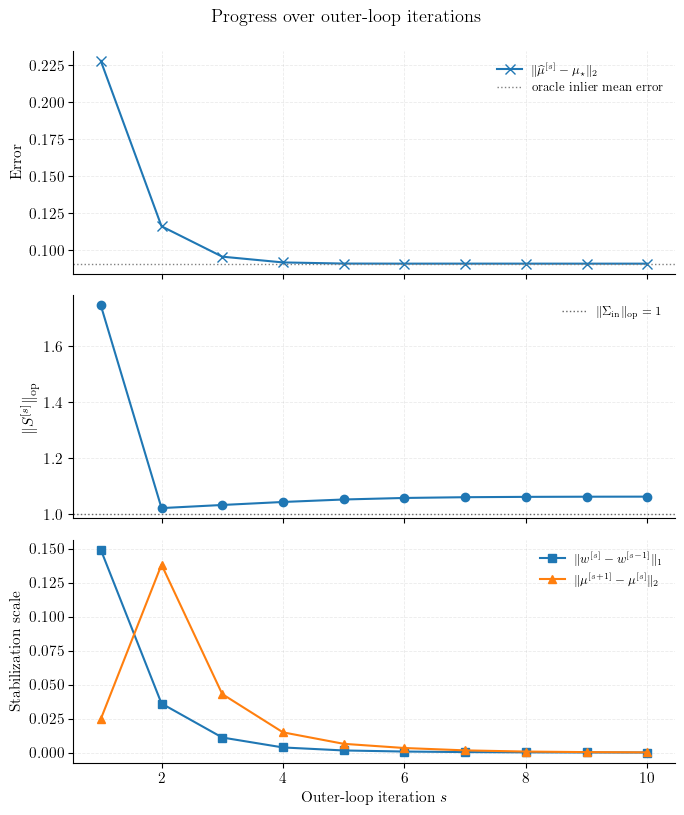

In [18]:
# ------------------------------------------------------------------
# 2. fig_outer_iterations.pdf
#    This uses diagnostic_history and diagnostic_results_df from cells 17--18.
# ------------------------------------------------------------------
s = np.arange(1, len(diagnostic_history["spectral_norm_history"]) + 1)
oracle_error = float(diagnostic_results_df["oracle_inlier_mean_error"].iloc[0])

fig, axes = plt.subplots(3, 1, figsize=(6.9, 8.2), sharex=True)
fig.suptitle("Progress over outer-loop iterations", y=0.99)

axes[0].plot(s, diagnostic_history["location_error_history"], marker="x", markersize=7,
             label=r"$\|\widehat{\mu}^{[s]} - \mu_\star\|_2$")
axes[0].axhline(oracle_error, color="0.5", linestyle=":", linewidth=1.0,
                label="oracle inlier mean error")
axes[0].set_ylabel("Error")
axes[0].legend(loc="upper right", fontsize=9)

axes[1].plot(s, diagnostic_history["spectral_norm_history"], marker="o")
axes[1].axhline(1.0, color="0.4", linestyle=":", linewidth=1.0,
              label=r"$\|\Sigma_{\mathrm{in}}\|_{\mathrm{op}} = 1$")
axes[1].set_ylabel(r"$\|S^{[s]}\|_{\mathrm{op}}$")
axes[1].legend(loc="upper right", fontsize=9)

axes[2].plot(s, diagnostic_history["weight_change_history"], marker="s",
             label=r"$\|w^{[s]} - w^{[s-1]}\|_1$")
axes[2].plot(s, diagnostic_history["center_shift_history"], marker="^",
             label=r"$\|\mu^{[s+1]} - \mu^{[s]}\|_2$")
axes[2].set_xlabel(r"Outer-loop iteration $s$")
axes[2].set_ylabel("Stabilization scale")
axes[2].legend(loc="upper right", fontsize=9)

fig.tight_layout()
plt.show() 

In [39]:
print("Final robust weighted-mean error:", diagnostic_results_df["robust_weighted_mean_error"].iloc[-1])

Final robust weighted-mean error: 0.09107858392529236


In [34]:
print("Weight update decrease from", diagnostic_history["weight_change_history"][0], "to", diagnostic_history["weight_change_history"][-1])


Weight update decrease from 0.14928923362917404 to 3.226234477617391e-05


In [35]:
print("Fixed center update decrease from", diagnostic_history["center_shift_history"][0], "to", diagnostic_history["center_shift_history"][-1])

Fixed center update decrease from 0.024669590651649306 to 0.00014798420245244027


In [40]:
print("Spectral norm decreases from", diagnostic_history["spectral_norm_history"][0], "to", diagnostic_history["spectral_norm_history"][-1])

Spectral norm decreases from 1.7467355790601948 to 1.0622836790728971


In [22]:
from scipy.io import loadmat, savemat
savemat(os.path.join(parent_directory,  'tests/test_data', 'diagnostic_history.mat'), diagnostic_history) 
diagnostic_results_df.to_csv(os.path.join(parent_directory,  'tests/test_data', 'diagnostic_results_df.csv'), index=True)
save_pdf(fig, "fig_outer_iterations.pdf")

saved: figures/fig_outer_iterations.pdf



### Experiment 3: sensitivity to the assumed contamination fraction

As in the original notebook, the capped simplex requires a user-specified
contamination level. The updated implementation should still be much more
forgiving to mild overestimation than to underestimation.


In [23]:

epsilon_assumption_results = []

for epsilon_assumed in epsilon_assumption_grid:
    config = SyntheticGradientExperimentConfig(
        n_inliers=540,
        n_outliers=60,
        dim_p=10,
        epsilon_assumed=epsilon_assumed,
        outlier_mode="directional_smallest_eigenvector",
        outlier_strength=8.0,
        use_exact_diameter=True,
        step_max_outer=8,
        step_max_inner=100,
        step_size_strategy="max_safe",
        target_accuracy=1e-4,
        warm_start_inner_weights=True,
        initial_center_strategy="geometric_median",
    )
    result_df, _ = run_repeated_trials(config, seed_grid)
    epsilon_assumption_results.append(result_df)

epsilon_assumption_results_df = pd.concat(epsilon_assumption_results, ignore_index=True)
epsilon_assumption_summary_df = summarise_metric(
    epsilon_assumption_results_df,
    group_cols=["epsilon_assumed"],
    metric_cols=[
        "robust_weighted_mean_error",
        "robust_outlier_mass",
        "robust_second_moment_spectral_norm_at_fixed_center",
    ],
)
epsilon_assumption_summary_df


,epsilon_assumed,robust_weighted_mean_error_mean,robust_weighted_mean_error_std,robust_outlier_mass_mean,robust_outlier_mass_std,robust_second_moment_spectral_norm_at_fixed_center_mean,robust_second_moment_spectral_norm_at_fixed_center_std
0,0.05,0.419977,0.012307,0.052632,1.439904e-17,3.146269,0.035127
1,0.08,0.190073,0.015217,0.021739,5.060997e-16,1.393772,0.021607
2,0.10,0.085506,0.025883,0.000076,6.818253e-05,1.027491,0.056056
3,0.12,0.086134,0.026352,0.000024,5.459821e-06,0.953827,0.048078
4,0.15,0.087017,0.026623,0.000020,4.437577e-06,0.897720,0.043069
5,0.20,0.088659,0.027176,0.000017,3.915718e-06,0.838663,0.039468


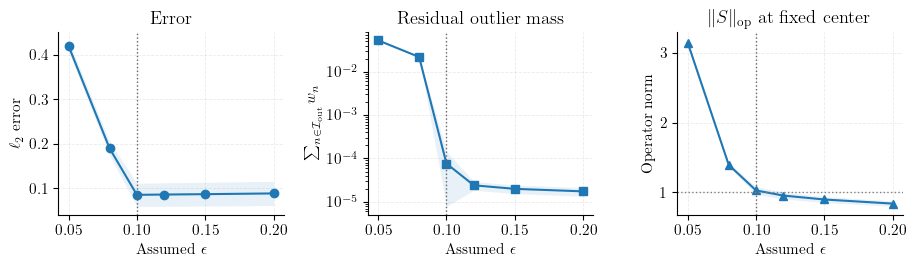

In [24]:
# ------------------------------------------------------------------
# 3. fig_epsilon_sensitivity.pdf
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(9.3, 2.8), sharex=True)
actual_eps = 0.10

plot_mean_with_band(axes[0], epsilon_assumption_summary_df, "epsilon_assumed",
                    "robust_weighted_mean_error_mean", "robust_weighted_mean_error_std",
                    "", marker="o")
axes[0].axvline(actual_eps, color="0.4", linestyle=":", linewidth=1.0)
axes[0].set_title("Error")
axes[0].set_xlabel(r"Assumed $\epsilon$")
axes[0].set_ylabel(r"$\ell_2$ error")

plot_mean_with_band(axes[1], epsilon_assumption_summary_df, "epsilon_assumed",
                    "robust_outlier_mass_mean", "robust_outlier_mass_std",
                    "", marker="s")
axes[1].axvline(actual_eps, color="0.4", linestyle=":", linewidth=1.0)
axes[1].set_yscale("log")
axes[1].set_title("Residual outlier mass")
axes[1].set_xlabel(r"Assumed $\epsilon$")
axes[1].set_ylabel(r"$\sum_{n\in\mathcal{I}_{\mathrm{out}}} w_n$")

plot_mean_with_band(axes[2], epsilon_assumption_summary_df, "epsilon_assumed",
                    "robust_second_moment_spectral_norm_at_fixed_center_mean",
                    "robust_second_moment_spectral_norm_at_fixed_center_std",
                    "", marker="^")
axes[2].axvline(actual_eps, color="0.4", linestyle=":", linewidth=1.0)
axes[2].axhline(1.0, color="0.5", linestyle=":", linewidth=1.0)
axes[2].set_title(r"$\|S\|_{\mathrm{op}}$ at fixed center")
axes[2].set_xlabel(r"Assumed $\epsilon$")
axes[2].set_ylabel("Operator norm")

fig.tight_layout()
plt.show() 


In [25]:
epsilon_assumption_results_df.to_csv(os.path.join(parent_directory,  'tests/test_data', 'epsilon_assumption_results_df.csv'), index=True) 
epsilon_assumption_summary_df.to_csv(os.path.join(parent_directory,  'tests/test_data', 'epsilon_assumption_summary_df.csv'), index=True)
save_pdf(fig, "fig_epsilon_sensitivity.pdf")

saved: figures/fig_epsilon_sensitivity.pdf
